In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import numpy as np

def direct_function(n, h, sigma, theta):
    """
    ТОЧНАЯ копия вашей функции с добавлением защиты от переполнения.
    """
    k_0 = 2 * np.pi / 0.154
    # Добавляем среду (вакуум = 1) и подложку
    n = np.concatenate((np.array([1.0 + 0j]), np.array(n), np.array([1 - 7.5772e-6 - 1.7261e-7j])))
    h = np.array(h, dtype=np.float64)
    theta = np.array(np.pi * theta / 180.0, dtype=np.float64)
    sigma = np.array(sigma, dtype=np.float64)

    # Вычисляем k_z — как у вас
    k_z_sq = n**2 * k_0**2 - k_0**2 * np.cos(theta)**2
    k_z = np.sqrt(k_z_sq.astype(complex))  # комплексный корень

    k_z_1 = k_z[:-1]
    k_z_2 = k_z[1:]

    # Защита от деления на ноль
    eps = 1e-30
    k_z_1_safe = np.where(np.abs(k_z_1) < eps, eps, k_z_1)

    p = (k_z_1 + k_z_2) / (2 * k_z_1_safe)
    q_z_1 = 2 * k_z_1
    q_z_2 = 2 * k_z_2

    # Защита в экспоненте шероховатости
    exponent = -q_z_1 * q_z_2 * sigma**2 / 2
    # Ограничиваем вещественную часть, чтобы избежать переполнения
    exponent_clipped = np.clip(np.real(exponent), -700, 700) + 1j * np.imag(exponent)
    m = ((k_z_1 - k_z_2) / (2 * k_z_1_safe)) * np.exp(exponent_clipped)

    # Матрицы отражения
    R = np.empty((len(m), 2, 2), dtype=complex)
    for i in range(len(m)):
        R[i, 0, 0] = p[i]
        R[i, 0, 1] = m[i]
        R[i, 1, 0] = m[i]
        R[i, 1, 1] = p[i]

    # Матрицы передачи — как у вас!
    expminus = np.exp(-1j * k_z[1:-1] * h)
    expplus = np.exp( 1j * k_z[1:-1] * h)

    # Защита: если экспоненты переполнились — возвращаем большое значение
    if np.any(np.isnan(expminus)) or np.any(np.isinf(expminus)) or \
       np.any(np.isnan(expplus)) or np.any(np.isinf(expplus)):
        return 1e20  # Штраф за численную нестабильность

    T = np.empty((len(h), 2, 2), dtype=complex)
    for i in range(len(h)):
        T[i, 0, 0] = expminus[i]
        T[i, 0, 1] = 0.0
        T[i, 1, 0] = 0.0
        T[i, 1, 1] = expplus[i]

    # Перемножение матриц — как у вас
    M = np.eye(2, dtype=complex)
    for k in range(len(h)):
        M = M @ R[k] @ T[k]
    M = M @ R[-1]

    # Проверка деления
    if np.abs(M[1, 1]) < 1e-30 or np.isnan(M[1, 1]) or np.isinf(M[1, 1]):
        return 1e20

    R_total = M[0, 1] / M[1, 1]
    I = np.abs(R_total) ** 2

    if np.isnan(I) or np.isinf(I):
        return 1e20

    return I

In [3]:
n = np.array([1 - 7.5772e-6 - 1.7261e-7j, 1 - 2.1126e-5 - 2.1529e-6j, 1 - 2.2456e-5 - 2.8977e-6j]) #Тут массив коэфов преломления
h = np.array([10, 10, 10]) #Тут массив толщин в нанометрах
Theta = np.arange(0.005, 4.5, 0.005) #Углы
sigma = np.array([1,1,1,1]) #Шероховатость
Int = []
for i in range(len(Theta)):
    Int.append(direct_function(n, h,sigma, Theta[i]))
Int = np.array(Int) #Теоретическая интенсивность при заданных параметрах, посчитана через функцию direct_function

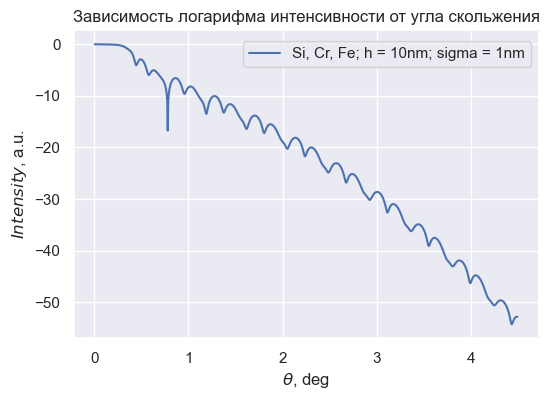

In [4]:
sns.set(style='darkgrid')
plt.figure(figsize=(6,4), dpi = 100)
plt.ylabel('$Intensity$, a.u.')
plt.xlabel(r'$\theta$, deg')
plt.title('Зависимость логарифма интенсивности от угла скольжения')
plt.plot(Theta, np.log(Int), label = 'Si, Cr, Fe; h = 10nm; sigma = 1nm') #Тут по оси у - логарифм коэфа отражения!!!
plt.legend(bbox_to_anchor=(1, 0.99))
plt.show()

In [5]:
def cost_function_h_sigma(params, theta_arr, I_arr, n_fixed):
    """
    params = [h0, h1, h2, sigma0, sigma1, sigma2, sigma3]
    """
    h = [9,9,9]
    sigma = params

    # Физические ограничения: толщины > 0, шероховатость ≥ 0
    if np.any(h <= 0) or np.any(sigma < 0):
        return 1e30

    total_error = 0.0
    for th, I_exp in zip(theta_arr, I_arr):
        try:
            I_model = direct_function(n_fixed, h, sigma, th)
        except Exception:
            return 1e30

        # Если результат не конечен — штраф
        if not np.isfinite(I_model) or I_model < 0:
            return 1e30

        total_error += abs(np.log(I_exp) - np.log(I_model) - np.max(np.log(data[:, 1])))

    return total_error

In [ ]:
data = np.load('data.npy')
plt.plot(data[:, 0], np.log(data[:, 1]))
Int = []
h_eps=[9,9,9]
s_eps =0# [-0.3,0,0,0]
print(np.log(data[0, 1]))
for i in range(len(Theta)):
    Int.append(direct_function(n_opt, h_eps, sigma_opt+ s_eps, Theta[i]))
Int = np.array(Int)
plt.plot(Theta, np.log(Int)+np.log(np.max(data[:, 1])), color = 'red')


In [6]:
n_si = 1 - 7.5772e-6 - 1.7261e-7j
n_cr = 1 - 2.1126e-5 - 2.1529e-6j
n_fe = 1 - 2.2456e-5 - 2.8977e-6j

n_fixed =  np.array([n_fe, n_si, n_cr])
# Генерация "экспериментальных" данных с известными h и sigma
h_true = np.array([12.0, 8.0, 15.0])       # реальные толщины
sigma_true = np.array([0.9, 1.1, 0.8, 1.2])  # реальные шероховатости

# Углы: начинаем с 0.15°, чтобы избежать экстремальных значений
theta_arr = np.arange(0.15, 4.0, 0.01)

# Вычисляем "измеренные" интенсивности
I_arr = np.array([
    direct_function(n_fixed, h_true, sigma_true, th)
    for th in theta_arr
])

# Добавим небольшой шум (реалистично)
np.random.seed(42)
I_arr_noisy = I_arr * (1 + 0.02 * np.random.randn(len(I_arr)))  # 2% шум
I_arr_noisy = np.clip(I_arr_noisy, 0, None)  # интенсивность ≥ 0

from scipy.optimize import minimize

# Начальные параметры (немного отличаются от истинных)
h0 = [10.0, 10.0, 10.0]
sigma0 = [1.0, 1.0, 1.0, 1.0]
initial_params = np.concatenate([sigma0])

# Границы: h ∈ [1, 100] нм, sigma ∈ [0.1, 5] нм
bounds = [
    (0.1, 1.0), (0.1, 1.0), (0.1, 1.0), (0.1, 1.0)  # sigma
]

# Запуск оптимизации
result = minimize(
    cost_function_h_sigma,
    initial_params,
    args=(data[:, 0], data[:, 1], n_fixed),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 200}
)

print("✅ Success:", result.success)
print("📉 Final cost:", result.fun)

if result.success:
    sigma_opt = result.x
    print("\n🎯 Истинные параметры:")
    print("\n🔬 Оптимизированные параметры:")
    print("h_opt     =", h_opt)
    print("sigma_opt =", sigma_opt)
else:
    print("❌ Оптимизация не удалась")

NameError: name 'data' is not defined